1. Import libraries and load IMD dataset

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


# Load IMD dataset

imd = pd.read_csv(
    r"C:\Users\kamru\Documents\AU\Monsoon project\imd_rainfall_monthly_2000_2025.csv"
)


imd.head()

,Year,Month,Rainfall_Monthly
0,2000,1,-22137.771777
1,2000,2,-20705.686712
2,2000,3,-22137.196368
3,2000,4,-21417.590856
4,2000,5,-22121.225537


2. Check Dataset Structure

In [8]:
print("="*50)
print("Shape")
print("="*50)

print(imd.shape)


print("\nColumns")
print("="*50)

print(imd.columns.tolist())


print("\nData Types")
print("="*50)

print(imd.dtypes)

Shape
(312, 3)

Columns
['Year', 'Month', 'Rainfall_Monthly']

Data Types
Year                  int64
Month                 int64
Rainfall_Monthly    float64
dtype: object


3. Basic Statistics

In [9]:
imd.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,312.0,2012.500000,7.512048,2000.000000,2006.000000,2012.500000,2019.00000,2025.000000
Month,312.0,6.500000,3.457598,1.000000,3.750000,6.500000,9.25000,12.000000
Rainfall_Monthly,312.0,-21713.980587,574.943680,-22141.030471,-22130.704253,-22067.544891,-21405.97593,-19987.284592


4. Missing Value Check

In [10]:
missing = imd.isnull().sum()

missing_percentage = (
    missing / len(imd)
) * 100


pd.DataFrame({
    "Missing": missing,
    "Percentage": missing_percentage
})

,Missing,Percentage
Year,0,0.0
Month,0,0.0
Rainfall_Monthly,0,0.0


5. Duplicate Check

In [11]:
print(
    "Duplicate rows:",
    imd.duplicated().sum()
)

Duplicate rows: 0


6. Check Year Coverage

In [12]:
print(
    "Minimum Year:",
    imd["Year"].min()
)


print(
    "Maximum Year:",
    imd["Year"].max()
)

Minimum Year: 2000
Maximum Year: 2025


7. If IMD Data is Monthly Format

In [14]:
imd["Date"] = pd.to_datetime(
    imd["Year"].astype(str)
    + "-"
    + imd["Month"].astype(str)
    + "-01"
)


imd.head()

,Year,Month,Rainfall_Monthly,Date
0,2000,1,-22137.771777,2000-01-01
1,2000,2,-20705.686712,2000-02-01
2,2000,3,-22137.196368,2000-03-01
3,2000,4,-21417.590856,2000-04-01
4,2000,5,-22121.225537,2000-05-01


8. Monthly Rainfall Trend

In [22]:
imd.columns

Index(['Year', 'Month', 'Rainfall_Monthly', 'Date'], dtype='str')

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Clean columns and find the rainfall column name
imd_long = imd.copy()
imd_long.columns = imd_long.columns.str.strip()
rain_col = next((c for c in imd_long.columns if any(x in c.lower() for x in ['rain', 'precip'])), 'Rainfall')

# 2. Force numeric types and drop NaNs
for col in ['Year', 'Month', rain_col]:
    imd_long[col] = pd.to_numeric(imd_long[col], errors='coerce')
imd_long = imd_long.dropna(subset=['Year', 'Month', rain_col])

# 3. Build Date, standardise name, and sort
imd_long['Date'] = pd.to_datetime(dict(year=imd_long['Year'].astype(int), month=imd_long['Month'].astype(int), day=1))
imd_long = imd_long.rename(columns={rain_col: 'Rainfall'}).sort_values('Date')

# 4. Preview in Jupyter (no print needed)
imd_long.head()

,Year,Month,Rainfall,Date
0,2000,1,-22137.771777,2000-01-01
1,2000,2,-20705.686712,2000-02-01
2,2000,3,-22137.196368,2000-03-01
3,2000,4,-21417.590856,2000-04-01
4,2000,5,-22121.225537,2000-05-01


9. Annual Monsoon Rainfall

In [30]:
import pandas as pd
import matplotlib.pyplot as plt


# =====================================
# Annual Southwest Monsoon Rainfall
# JJAS = June + July + August + September
# =====================================


# Select monsoon months
monsoon_months = [6, 7, 8, 9]


imd_monsoon = imd_long[
    imd_long["Month"].isin(monsoon_months)
]


# Calculate annual monsoon rainfall
annual_monsoon = (
    imd_monsoon
    .groupby("Year")["Rainfall"]
    .sum()
    .reset_index()
)


# Rename column
annual_monsoon = annual_monsoon.rename(
    columns={
        "Rainfall": "Annual_Monsoon_Rainfall"
    }
)


# Display result
annual_monsoon.head()

,Year,Annual_Monsoon_Rainfall
0,2000,-86914.336871
1,2001,-86909.858973
2,2002,-86939.891029
3,2003,-86882.794573
4,2004,-86920.465559


Plot 

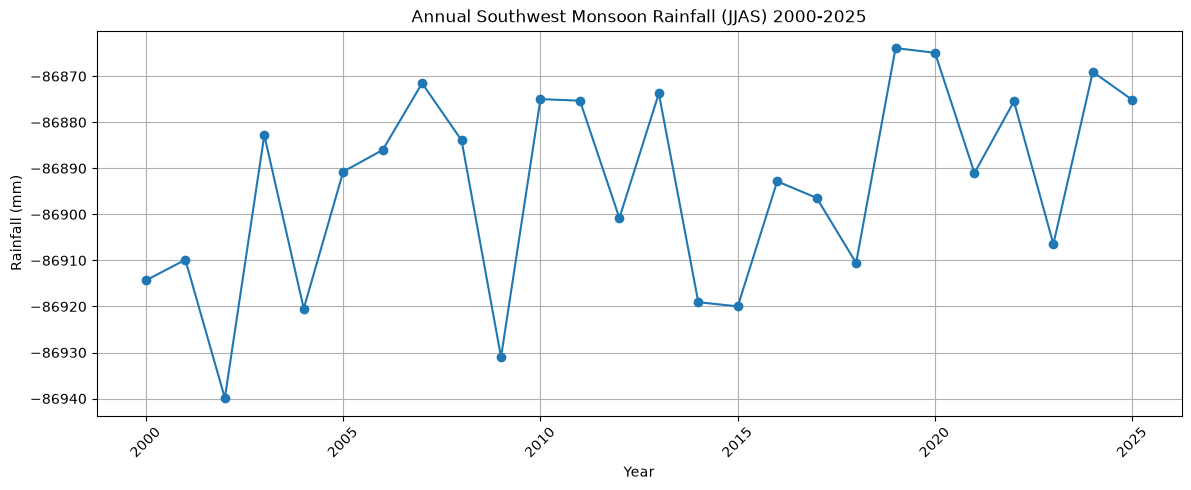

In [31]:
plt.figure(figsize=(14,5))


plt.plot(
    annual_monsoon["Year"],
    annual_monsoon["Annual_Monsoon_Rainfall"],
    marker="o"
)


plt.title(
    "Annual Southwest Monsoon Rainfall (JJAS) 2000-2025"
)


plt.xlabel(
    "Year"
)


plt.ylabel(
    "Rainfall (mm)"
)


plt.grid(True)


plt.xticks(
    rotation=45
)


plt.show()

Check drought and excess rainfall years

calculation of the average monsoon rainfall:

In [32]:
mean_monsoon = annual_monsoon[
    "Annual_Monsoon_Rainfall"
].mean()


print(
    "Average Monsoon Rainfall:",
    round(mean_monsoon,2),
    "mm"
)

Average Monsoon Rainfall: -86893.86 mm


10. Monthly Rainfall Seasonality

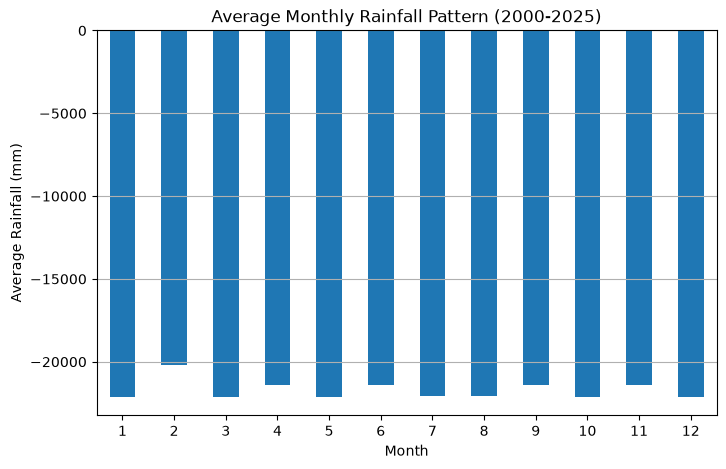

In [34]:
import matplotlib.pyplot as plt


# Calculate average rainfall for each month
monthly_avg = (
    imd_long
    .groupby("Month")["Rainfall"]
    .mean()
)


# Plot monthly rainfall pattern
plt.figure(figsize=(8,5))


monthly_avg.plot(
    kind="bar"
)


plt.title(
    "Average Monthly Rainfall Pattern (2000-2025)"
)


plt.xlabel(
    "Month"
)


plt.ylabel(
    "Average Rainfall (mm)"
)


plt.xticks(
    rotation=0
)


plt.grid(
    axis="y"
)


plt.show()

11. Rainfall Distribution

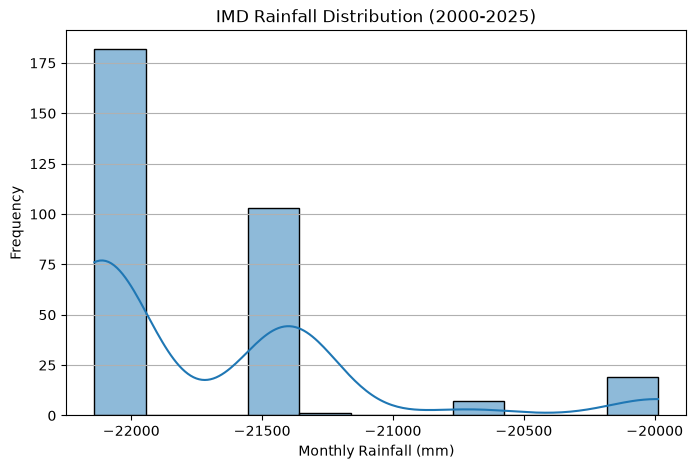

In [36]:
plt.figure(figsize=(8,5))


sns.histplot(
    data=imd_long,
    x="Rainfall",
    kde=True
)


plt.title(
    "IMD Rainfall Distribution (2000-2025)"
)


plt.xlabel(
    "Monthly Rainfall (mm)"
)


plt.ylabel(
    "Frequency"
)


plt.grid(
    axis="y"
)


plt.show()

numerical distribution:

In [37]:
imd_long["Rainfall"].describe()

count      312.000000
mean    -21713.980587
std        574.943680
min     -22141.030471
25%     -22130.704253
50%     -22067.544891
75%     -21405.975930
max     -19987.284592
Name: Rainfall, dtype: float64

12. Outlier Detection

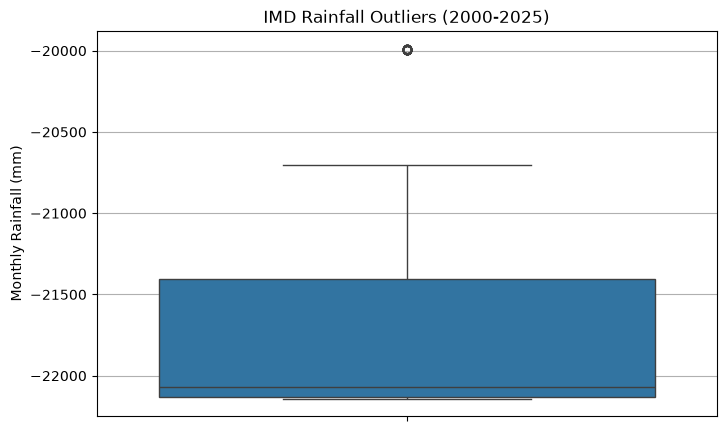

In [39]:
plt.figure(figsize=(8,5))


sns.boxplot(
    y=imd_long["Rainfall"]
)


plt.title(
    "IMD Rainfall Outliers (2000-2025)"
)


plt.ylabel(
    "Monthly Rainfall (mm)"
)


plt.grid(
    axis="y"
)


plt.show()

13. Yearly Rainfall Variability

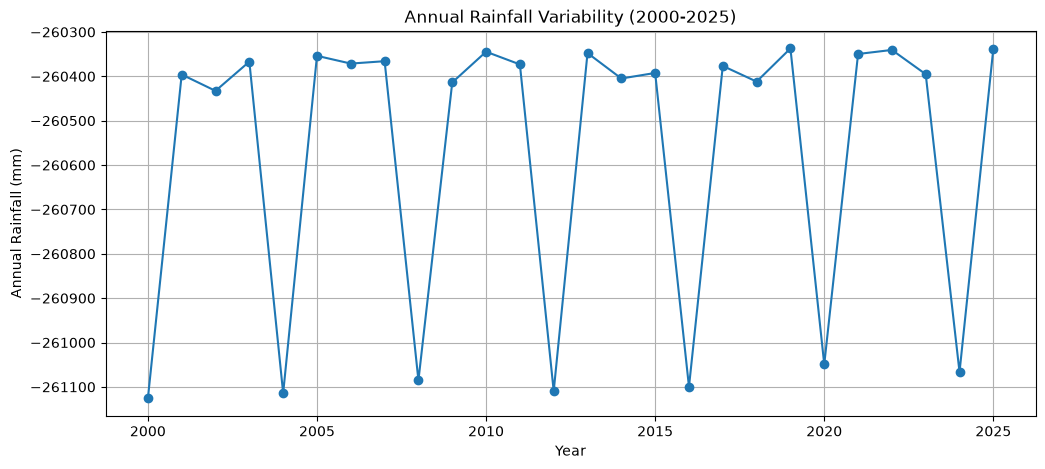

In [40]:
# Calculate annual rainfall
annual = (
    imd_long
    .groupby("Year")["Rainfall"]
    .sum()
)


# Plot annual rainfall variability
plt.figure(figsize=(12,5))


annual.plot(
    marker="o"
)


plt.title(
    "Annual Rainfall Variability (2000-2025)"
)


plt.xlabel(
    "Year"
)


plt.ylabel(
    "Annual Rainfall (mm)"
)


plt.grid(True)


plt.show()

14. Save Clean IMD EDA Dataset

In [41]:
import os

# Create outputs folder if it does not exist
os.makedirs(
    "outputs",
    exist_ok=True
)


# Save cleaned IMD EDA dataset
imd_long.to_csv(
    "outputs/imd_eda_ready.csv",
    index=False
)


print(
    "IMD EDA dataset saved successfully"
)

IMD EDA dataset saved successfully
